In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

In [3]:
n = 100000

In [4]:
data = pd.DataFrame({
    "Customer_ID": range(1, n+1),
    "Age": np.random.randint(18, 71, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Tenure": np.random.randint(0, 11, n),
    "Balance": np.random.randint(0, 200001, n),
    "CreditScore": np.random.randint(300, 901, n),
    "EstimatedSalary": np.random.randint(10000, 150001, n),
    "NumOfProducts": np.random.randint(1, 5, n),
    "IsActiveMember": np.random.choice(["Yes", "No"], n)
})

In [5]:
data["Churn"] = np.where(
    ((data["Balance"] < 50000) & (data["IsActiveMember"] == "No")) |
    ((data["CreditScore"] < 400) & (data["Tenure"] < 3)) |
    ((data["NumOfProducts"] == 1) & (data["IsActiveMember"] == "No")),
    1,
    0
)

In [6]:
print("Dataset Created Successfully!\n")
print(data.head())



Dataset Created Successfully!

   Customer_ID  Age  Gender  Tenure  Balance  CreditScore  EstimatedSalary  \
0            1   56  Female       3   138803          718           121992   
1            2   69    Male       1   174102          534           125877   
2            3   46  Female      10    90135          653            39062   
3            4   32    Male       6   160284          787            66364   
4            5   60  Female       6    24298          681           116045   

   NumOfProducts IsActiveMember  Churn  
0              4             No      0  
1              2             No      0  
2              2            Yes      0  
3              2            Yes      0  
4              2            Yes      0  


In [7]:
data.to_csv("customer_churn_data.csv", index=False)


In [8]:
print("\n--- Data Info ---")
print(data.info())



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Customer_ID      100000 non-null  int64 
 1   Age              100000 non-null  int64 
 2   Gender           100000 non-null  object
 3   Tenure           100000 non-null  int64 
 4   Balance          100000 non-null  int64 
 5   CreditScore      100000 non-null  int64 
 6   EstimatedSalary  100000 non-null  int64 
 7   NumOfProducts    100000 non-null  int64 
 8   IsActiveMember   100000 non-null  object
 9   Churn            100000 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 7.6+ MB
None


In [9]:
print("\n--- Missing Values ---")
print(data.isnull().sum())



--- Missing Values ---
Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64


In [10]:
data = data.dropna()

In [11]:
print("\n--- Statistical Summary ---")
print(data.describe())




--- Statistical Summary ---
         Customer_ID            Age         Tenure        Balance  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean    50000.500000      43.984060       4.988760   99742.233670   
std     28867.657797      15.251827       3.163744   57670.541911   
min         1.000000      18.000000       0.000000       0.000000   
25%     25000.750000      31.000000       2.000000   49819.000000   
50%     50000.500000      44.000000       5.000000   99729.000000   
75%     75000.250000      57.000000       8.000000  149691.250000   
max    100000.000000      70.000000      10.000000  200000.000000   

         CreditScore  EstimatedSalary  NumOfProducts          Churn  
count  100000.000000    100000.000000  100000.000000  100000.000000  
mean      599.942750     79959.021360       2.501980       0.253050  
std       173.269555     40445.277417       1.117734       0.434762  
min       300.000000     10000.000000       1.000000       0.000000  

In [12]:
data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})
data["IsActiveMember"] = data["IsActiveMember"].map({"No": 0, "Yes": 1})


In [13]:
print("\n--- Churn Count ---")
print(data["Churn"].value_counts())



--- Churn Count ---
Churn
0    74695
1    25305
Name: count, dtype: int64


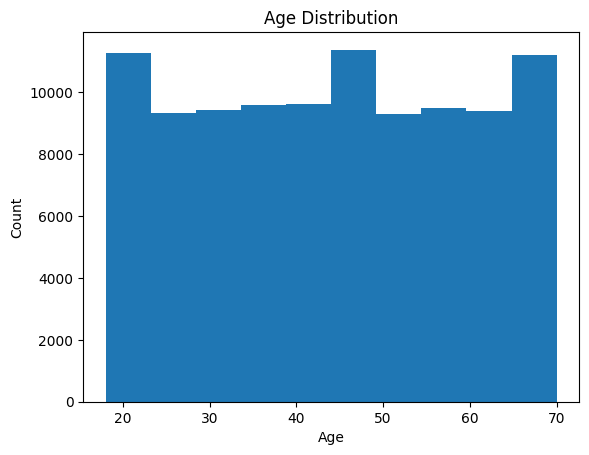

In [14]:
plt.hist(data["Age"])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


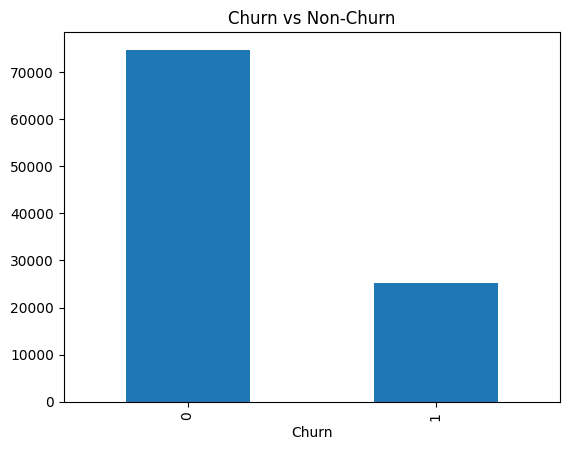

In [15]:
data["Churn"].value_counts().plot(kind='bar')
plt.title("Churn vs Non-Churn")
plt.show()


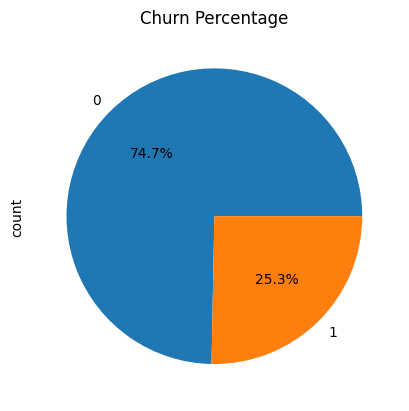

In [16]:
data["Churn"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Churn Percentage")
plt.show()


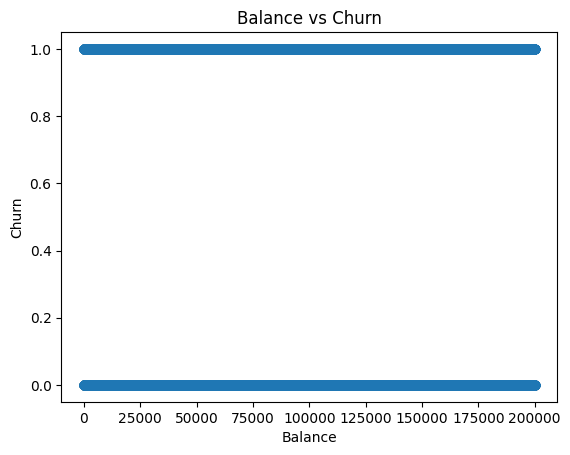

In [17]:
plt.scatter(data["Balance"], data["Churn"])
plt.xlabel("Balance")
plt.ylabel("Churn")
plt.title("Balance vs Churn")
plt.show()


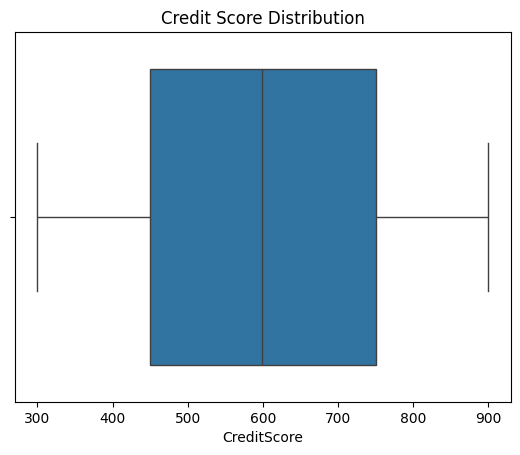

In [18]:
sns.boxplot(x=data["CreditScore"])
plt.title("Credit Score Distribution")
plt.show()

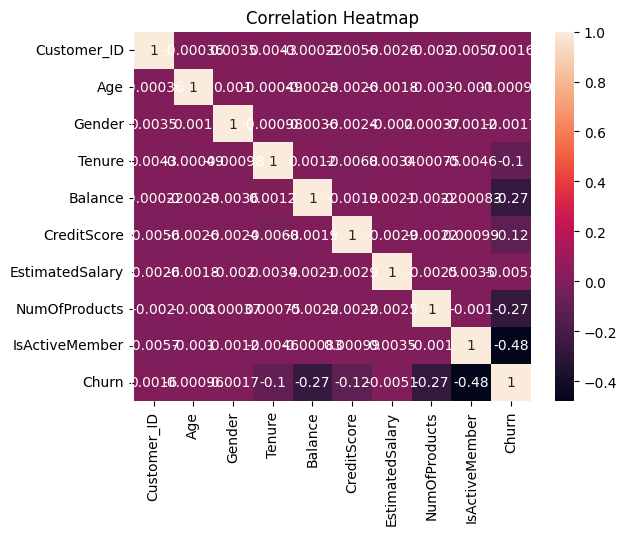

In [19]:
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()



In [20]:
print("\n--- Gender vs Churn ---")
print(data.groupby("Gender")["Churn"].value_counts())


--- Gender vs Churn ---
Gender  Churn
0       0        37393
        1        12716
1       0        37302
        1        12589
Name: count, dtype: int64


In [21]:
print("\n--- Active Member vs Churn ---")
print(data.groupby("IsActiveMember")["Churn"].value_counts())



--- Active Member vs Churn ---
IsActiveMember  Churn
0               0        27008
                1        23099
1               0        47687
                1         2206
Name: count, dtype: int64


In [22]:
print("\n--- Products vs Churn ---")
print(data.groupby("NumOfProducts")["Churn"].value_counts())




--- Products vs Churn ---
NumOfProducts  Churn
1              1        12896
               0        12041
2              0        20792
               1         4165
3              0        20973
               1         4104
4              0        20889
               1         4140
Name: count, dtype: int64


In [23]:
high_churn = data[data["Churn"] == 1]


In [24]:
print("\nTotal Churn Customers:", len(high_churn))
print(high_churn.head())



Total Churn Customers: 25305
    Customer_ID  Age  Gender  Tenure  Balance  CreditScore  EstimatedSalary  \
15           16   57       0       1    71179          723           132562   
17           18   20       0       2   137414          670           105630   
20           21   19       1       5    23181          329            32904   
28           29   29       0       1     6961          325            40974   
35           36   45       1       5   151958          530            95985   

    NumOfProducts  IsActiveMember  Churn  
15              1               0      1  
17              1               0      1  
20              4               0      1  
28              4               0      1  
35              1               0      1  
